# Image Quality (QI) Analysis

# Packages

In [2]:
packages <- list("lme4", "glmmTMB", "ggeffects")
for (pack in packages) {
    if (!requireNamespace(pack, quietly = TRUE)) {
      print(paste('Installing', pack))
      install.packages(pack)
    }
}

In [2]:
library(readr)
library(lme4)
library(glmmTMB)
library(ggplot2)
library(ggeffects)

Loading required package: Matrix



# Read Dataset

In [89]:
dataset_v0 = read_csv("data/dataset/suited_dataset.csv", show_col_types = FALSE)
dim(dataset_v0)

[1] 1772    9

In [90]:
ds_qi_per_img = read_csv("output/qi_per_img_3.csv", show_col_types = FALSE)
dim(ds_qi_per_img)

[1] 1772    2

In [91]:
dataset_v1 = merge(x = dataset_v0, y = ds_qi_per_img, by='depth')
dim(dataset_v1)

[1] 1772   10

In [92]:
dataset_v1 <- dataset_v1[,-c(1, 5, 6, 9)]
head(dataset_v1)

,farm,animal_id,weight,captured_at_as_min,unexpected_behavior,qi
,<chr>,<chr>,<dbl>,<dbl>,<lgl>,<dbl>
1,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,3305.927
2,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,3338.609
3,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,3289.363
4,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,3317.456
5,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,3379.749
6,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,3374.645


In [93]:
dataset_v1$farm = ifelse(dataset_v1$farm == 'Farm A', "Morning (Farm A)", "Afternoon (Farm B)")

In [94]:
dataset_v1$farm  = as.factor(dataset_v1$farm)
dataset_v1$unexpected_behavior = as.factor(dataset_v1$unexpected_behavior)
dataset_v1$animal_id = as.factor(dataset_v1$animal_id)

head(dataset_v1)

,farm,animal_id,weight,captured_at_as_min,unexpected_behavior,qi
,<fct>,<fct>,<dbl>,<dbl>,<fct>,<dbl>
1,Afternoon (Farm B),amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,3305.927
2,Afternoon (Farm B),amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,3338.609
3,Afternoon (Farm B),amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,3289.363
4,Afternoon (Farm B),amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,3317.456
5,Afternoon (Farm B),amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,3379.749
6,Afternoon (Farm B),amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,3374.645


In [96]:
# Function to normalize a numeric vector to a 0-1 range
normalize <- function(x) {
  vl <- ((x - min(x, na.rm = TRUE)) / (max(x, na.rm = TRUE) - min(x, na.rm = TRUE)))
  vl + 0.0001
}

In [97]:
dataset_v1$captured_at_as_min <- normalize(dataset_v1$captured_at_as_min)
dataset_v1$qi <- normalize(dataset_v1$qi)
dataset_v1$weight <- normalize(dataset_v1$weight)

# Model Evaluation

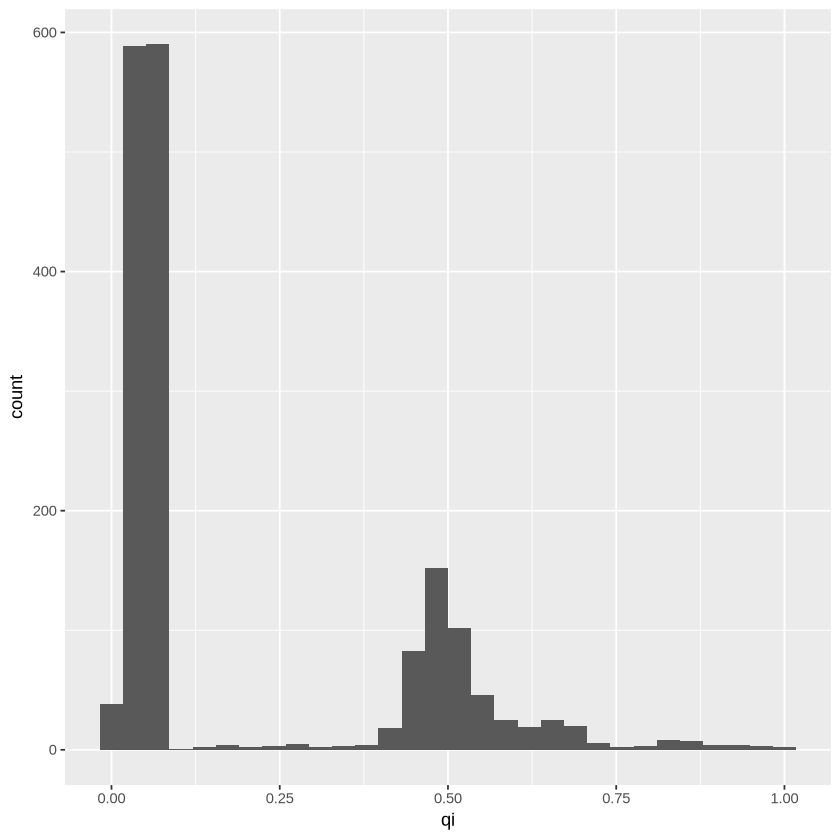

In [16]:
ggplot(dataset_v1, aes(x = qi)) + geom_histogram(bins = 30)

## Adjusting models

In [55]:
model1 <- lme4::glmer(
  'qi ~ farm + captured_at_as_min + weight + unexpected_behavior + (1|animal_id)',
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(model1)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: qi ~ farm + captured_at_as_min + weight + unexpected_behavior +  
    (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -9203.7   -9165.3    4608.8   -9217.7      1765 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.7967 -0.3655  0.0113  0.4456  4.3469 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.8485   0.9211  
Number of obs: 1772, groups:  animal_id, 190

Fixed effects:
                        Estimate Std. Error t value Pr(>|z|)    
(Intercept)             -3.62065    0.43959  -8.236   <2e-16 ***
farmMorning (Farm A)     2.95264    0.35045   8.425   <2e-16 ***
captured_at_as_min       0.52015    0.45251   1.149    0.250    
weight                  -0.29243    0.15964  -1.832    0.067 .  
unexpected_behaviorTRUE  0.08603    0.06608   1.302    0.193    
---
Signif. 

In [49]:
model2 <- lme4::glmer(
  'qi ~ farm + captured_at_as_min + weight + (1|animal_id)',
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(model2)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: qi ~ farm + captured_at_as_min + weight + (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -9204.0   -9171.1    4608.0   -9216.0      1766 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.7907 -0.3691  0.0105  0.4473  4.3549 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.8575   0.926   
Number of obs: 1772, groups:  animal_id, 190

Fixed effects:
                     Estimate Std. Error t value Pr(>|z|)    
(Intercept)           -3.6210     0.4430  -8.174 2.99e-16 ***
farmMorning (Farm A)   2.9686     0.3530   8.411  < 2e-16 ***
captured_at_as_min     0.5562     0.4552   1.222    0.222    
weight                -0.3103     0.1603  -1.935    0.053 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) fM(

In [98]:
model3 <- lme4::glmer(
  'qi ~ farm * captured_at_as_min + weight + (1|animal_id)',
  data = dataset_v1,
  family = Gamma(link = 'log')
)
summary(model3)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: qi ~ farm * captured_at_as_min + weight + (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -9210.9   -9172.6    4612.5   -9224.9      1765 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.8491 -0.3724  0.0210  0.4630  4.4333 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.8018   0.8954  
Number of obs: 1772, groups:  animal_id, 190

Fixed effects:
                                        Estimate Std. Error t value Pr(>|z|)   
(Intercept)                               0.3230     1.3520   0.239  0.81119   
farmMorning (Farm A)                     -0.9610     1.3230  -0.726  0.46761   
captured_at_as_min                       -3.6252     1.4293  -2.536  0.01120 * 
weight                                   -0.4943     0.1647  -3.001  0.00269 **
farmMorning (Farm A):captured_

In [51]:
model3 <- lme4::glmer(
  'qi ~ farm * weight + captured_at_as_min + (1|animal_id)',
  data = dataset_v1,
  family = Gamma(link = 'log')
)
summary(model3)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0688366 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: qi ~ farm * weight + captured_at_as_min + (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -9202.3   -9164.0    4608.2   -9216.3      1765 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.7951 -0.3686  0.0054  0.4493  4.3556 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.865    0.93    
Number of obs: 1772, groups:  animal_id, 190

Fixed effects:
                             Estimate Std. Error t value Pr(>|z|)    
(Intercept)                 -3.558948   0.001055 -3372.5   <2e-16 ***
farmMorning (Farm A)         2.878386   0.001055  2728.8   <2e-16 ***
weight                      -0.428013   0.001055  -405.6   <2e-16 ***
captured_at_as_min           0.531128   0.001056   503.2   <2e-16 ***
farmMorning (Farm A):weight  0.213319   0.001055   202.2   <2e-16 ***
---
Signif

In [54]:
model4 <- lme4::glmer(
  'qi ~ farm * captured_at_as_min * weight + (1|animal_id)',
  data = dataset_v1,
  family = Gamma(link = 'log')
)
summary(model4)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0687058 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: qi ~ farm * captured_at_as_min * weight + (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -9218.4   -9163.6    4619.2   -9238.4      1762 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.9022 -0.3742  0.0174  0.4494  4.4782 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.7431   0.862   
Number of obs: 1772, groups:  animal_id, 190

Fixed effects:
                                                 Estimate Std. Error   t value
(Intercept)                                      8.322129   0.001045   7965.50
farmMorning (Farm A)                            -9.188553   0.001044  -8799.03
captured_at_as_min                             -11.944422   0.001045 -11431.76
weight                                         -25.130102   0.001045 -24053.66
farmMorning (Farm A):captured_at_as

## Effect Analysis

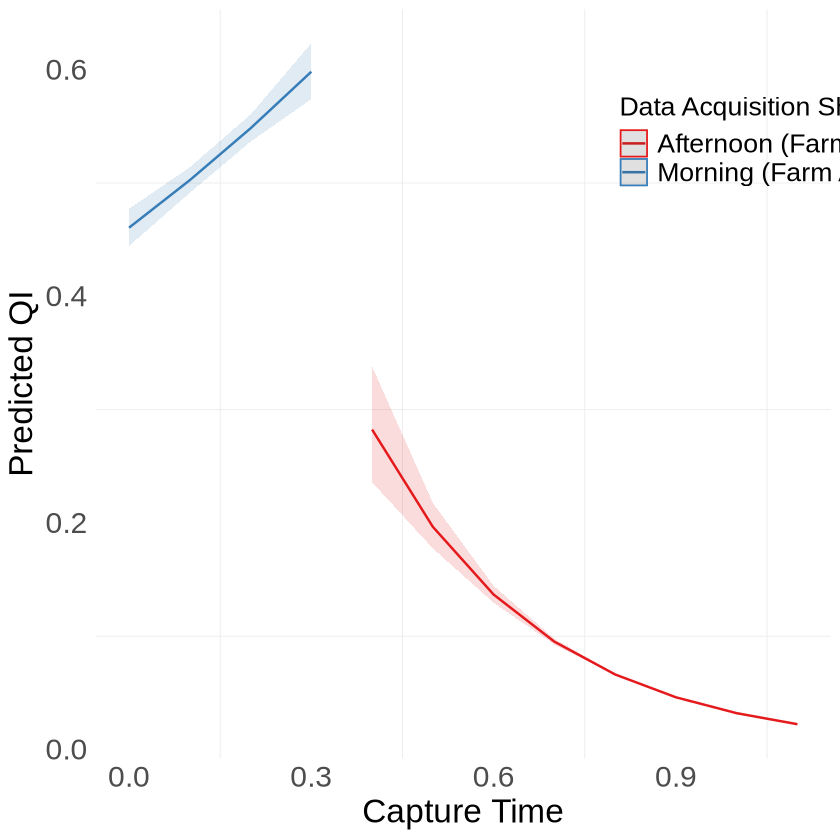

In [103]:
eff1 <- ggpredict(model3, terms = c("captured_at_as_min", "farm"))

eff1_filtered <- eff1[
  (eff1$group == "Morning (Farm A)"   & eff1$x < 0.35) | 
  (eff1$group == "Afternoon (Farm B)" & eff1$x > 0.35)
]

cha1 <- plot(eff1_filtered) +
  labs(
    title = NULL,  
    x = "Capture Time",
    y = "Predicted QI",
    color = "Data Acquisition Shift"
  ) +
  theme_minimal() +
  theme(
    legend.position = "inside",  # Coordinates
    legend.position.inside = c(0.7, 0.9),  
    legend.justification = c("left", "top"),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 18),
    legend.text = element_text(size = 16),
    legend.title = element_text(size = 16),
    panel.grid.major = element_blank(), 
    # panel.grid.minor = element_blank()
  )

cha1
ggsave(
  "output/qi_effect_time_x_farm.png",
  cha1,
  width = 12,
  height = 5,
  dpi = 600,
)